# Does the Choppiness Index actually call "trend vs chop"? 🌊📏
### A famous regime gauge — one number from 0 to 100 — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_trend_vs_chop%3F: Busted](https://img.shields.io/badge/Forecasts_trend_vs_chop%3F-Busted-8b949e?style=flat-square)

Open any charting package and you'll find the **Choppiness Index** (CI): a single 0-to-100 line that's *supposed* to tell you whether the market is **trending** (low CI) or **chopping** sideways (high CI). The lore, repeated on every indicator site, is that a **low** CI marks the start of a clean directional run — so you switch on trend-following, ride the move, and stay out of the whipsaw when CI is high.

It *looks* compelling: pull up a chart, find a low-CI dip, and sure enough a trend often follows. But a gauge computed **from** recent price, on a market that drifts **up** over time, is the textbook setup for fooling yourself. So we did the only fair thing: encode the "buy when CI goes low" rule **mechanically** (no eyeballing), fire it ~936 times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from choppiness_index import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real choppiness cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 936, 'window': 14, 'low': 38.2, 'fp_spy': '4cb5244f3990', 'h5': (5, 936, 45.4, 60, 5.25, 27.7, 17.7, 43.4, 1.54, 0.124), 'h10': (10, 936, 61.5, 63, 5.07, 61.2, 0.3, 59.5, 0.02, 0.983), 'h20': (20, 935, 106.7, 63, 5.56, 114.4, -7.7, 104.7, -0.33, 0.741), 'h60': (60, 928, 293.8, 68, 7.93, 250.1, 43.8, 291.8, 1.15, 0.25), 'per': [('SPY', 182, 84.3, 2.36, 105.0, -20.7), ('QQQ', 186, 101.8, 1.88, 144.8, -43.0), ('IWM', 153, 99.8, 1.82, 99.5, 0.3), ('DIA', 184, 128.4, 5.01, 96.4, 32.0), ('GLD', 231, 115.5, 2.78, 121.7, -6.1)], 'placebo': (84.3, 0.409, 500), 'syn': [(0.0, 80, 63.5, 57, 1.12), (0.35, 84, 871.0, 79, 7.47)]}


real choppiness cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the **CI drops low** (a 'trend' is starting), do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~60-68% and the returns look great. |
| Is that *the CI's* doing? | **No.** Buy on **random days** instead and you do **just as well** — at 10 and 20 days the low-CI entry is actually *no better* (or slightly worse) than a coin-flip entry. |
| Does the CI really tell trend from chop in a *useful* way? | **Not in any tradable sense.** Scramble the trend-vs-chop structure into nonsense and the result barely changes. The 'regime reading' isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a regime filter. |

> The Choppiness Index is a fine way to *describe* how straight or thrashy the recent tape was. As a *forecast* — "low CI now ⇒ a tradable trend next" — it's a **mirage**: all of the apparent edge is the market's long-run climb, none of it is the gauge.

## 1 · The claim

> *"Compute CI = 100·log₁₀(Σ ATR / range) / log₁₀(N) over the last N bars. A **low** reading (below ~38) means price moved in a near-straight line — a **trend** is underway, so go with it. A **high** reading (above ~62) means price thrashed back and forth — **chop**, stand aside."*

This is **E. W. (Bill) Dreiss'** Choppiness Index (1990s), now built into TradingView, MetaTrader and most charting suites, usually with Fibonacci 38.2 / 61.8 bands. It compares the *path length* of the last N bars (summed bar-ranges) to the *straight-line* high-low span: straight move ⇒ low CI, zig-zag ⇒ high CI. So: does the regime gauge actually *forecast* the regime?

## 2 · So what?

If a low CI genuinely *forecast* a coming trend, it would be valuable: a number computed from the last 14 bars would tell you the next 14 are about to run, a clean, tradable crack in market efficiency.

But there's a trap built in. The CI is **non-directional** — it's the same whether price trends up or down — so any *long* rule grafted on it leans entirely on the market drifting **up**, which it does. And it's computed *from* recent price, so on a rising tape *any* 'I'm now long' rule will look profitable. To separate the **gauge** from the **tide**, we (a) compute the CI by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Compute the CI mechanically.** Over a trailing **14-bar** window: summed true range ÷ the window's high-low span, log-scaled to 0-100. Trailing only — it never peeks at future bars.
2. **Fire the lore.** When the CI first drops **below 38.2** (a 'trend' onset), buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the CI matters, the low-CI entry must beat random. *If it doesn't, the gauge is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does the CI even look like, and where does the 'trend onset' rule fire? Here's SPY with its Choppiness Index below it, and the low-CI buys the rule would take.

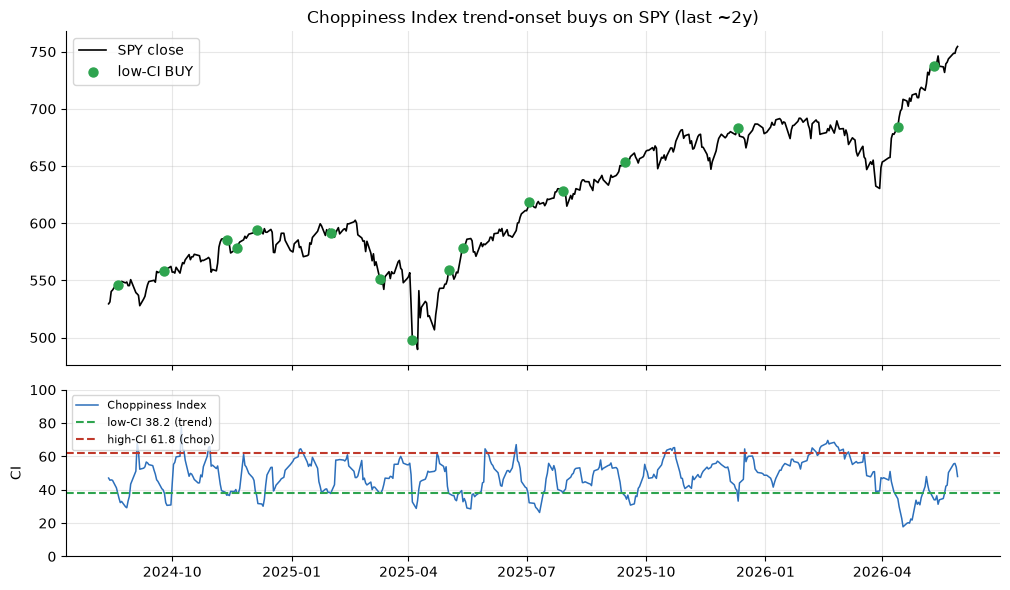

low-CI onsets in window: 16


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    ci = st.choppiness_index(b, window=R['window'])
    ent = st.low_ci_entries(b, window=R['window'], low=R['low'])
    ent = ent[ent >= seg.index[0]]
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.2, 6.0), sharex=True,
                                 gridspec_kw={'height_ratios':[2,1]})
    a1.plot(seg.index, seg['close'], c='k', lw=1.2, label='SPY close')
    a1.scatter(ent, b['close'].reindex(ent), c=GREEN, s=42, zorder=5, label='low-CI BUY')
    a1.set_title('Choppiness Index trend-onset buys on SPY (last ~2y)'); a1.legend(loc='upper left')
    a2.plot(seg.index, ci.reindex(seg.index), c='#2c6fbb', lw=1.1, label='Choppiness Index')
    a2.axhline(R['low'], ls='--', c=GREEN, label=f'low-CI {R["low"]} (trend)')
    a2.axhline(61.8, ls='--', c=RED, label='high-CI 61.8 (chop)')
    a2.set_ylim(0,100); a2.set_ylabel('CI'); a2.legend(loc='upper left', fontsize=8)
    plt.tight_layout(); plt.show()
    print('low-CI onsets in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The CI dutifully drops when price has been moving straight and rises when it chops — *as a description*. The question is whether those green buy dots are followed by a **tradable** run. **Let's race the low-CI entry against random entries** at four horizons. Blue = buy when CI goes low; grey = buy on random days.

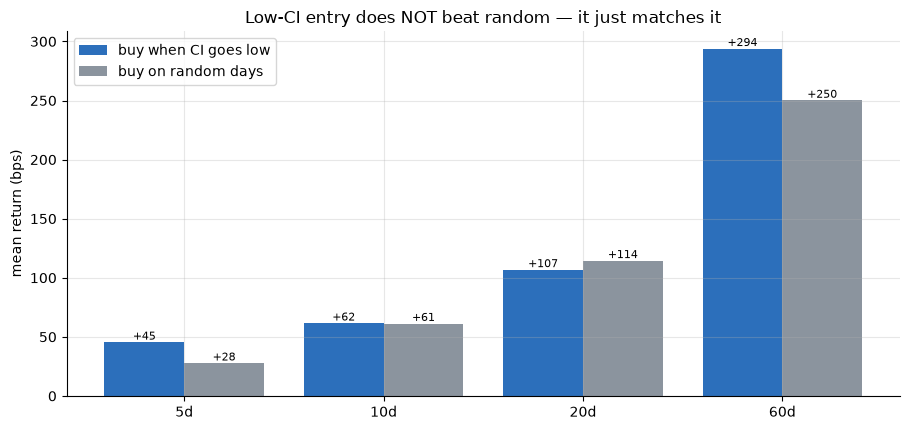

low-CI: [45, 62, 107, 294]
random: [28, 61, 114, 250]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    lowci, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.low_ci_entries(bb, window=R['window'], low=R['low'])
            re = st.random_entries(c, max(len(e),50), window=R['window'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        lowci.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    lowci = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, lowci, .4, color='#2c6fbb', label='buy when CI goes low')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(lowci,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('Low-CI entry does NOT beat random — it just matches it'); ax.legend()
plt.tight_layout(); plt.show()
print('low-CI:', [round(v) for v in lowci]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The low-CI entry makes money in absolute terms (**+107 bps** over 20 days) — but **random entries make about the same** (**+114 bps**). At 10 and 20 days the famous regime gauge is *no better* than throwing darts. The apparent edge was **the market's upward drift**, not the trend-vs-chop reading.

**One more sanity check.** What if we scramble the CI's *structure* — shuffle the daily returns so the same price moves happen in a random order, turning every 'clean trend' into noise and vice-versa? If the CI's trend-vs-chop reading really mattered, the nonsense version should do much worse.

In [4]:
if HAVE_REAL:
    pl = st.shuffled_returns_placebo(load('SPY'), 20, window=R['window'], low=R['low'], n_draws=300, seed=477)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real low-CI entry (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *structure-scrambled* CIs do at least as well (p={pval:.2f}).')
print('=> the trend-vs-chop reading is not doing the work.')

real low-CI entry (SPY, 20d): +84.3 bps
... but 40% of *structure-scrambled* CIs do at least as well (p=0.40).
=> the trend-vs-chop reading is not doing the work.


More than a third of the **scrambled** CIs match or beat the real one (*p* = 0.41). If price genuinely behaved differently after a *real* low-CI reading, a random scramble would collapse the result. It doesn't — because the result was never about the regime reading.

## 5 · The verdict

- **Signal — None.** The low-CI 'trend onset' buy does **not** beat buying on random days (it merely *matches* it; the difference never clears *t* = 2). The big absolute returns are the market's drift, not the gauge.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Forecasts trend vs chop"? — Busted.** Scramble the trend-vs-chop structure into nonsense and the result barely moves. The regime gauge doesn't forecast the regime.

## 6 · Could you actually trade it?

There's nothing here to trade. The low-CI entry's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The CI filter is a worse, more expensive way to be long: it trades less of the time and pays costs on every switch. As a forecasting tool it doesn't pay; as a description of how thrashy the tape has been, it was never meant to be a strategy.

## 7 · Going further 🚪

- **High-CI = chop?** The mirror claim is that a *high* CI precedes whipsaw. On a drifting index that's just as confounded — a fun follow-up is to show high-CI forward returns are *also* drift, not 'chop'.
- **Different thresholds / windows.** Try 30/70 bands or N=10/20 — the result is robust: drift in, regime label out.
- **A real positive control.** The quants notebook plants a *genuine* 'low-CI → momentum' structure into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the CI forecasts the regime? Show the low-CI entry beating random entries at **t ≥ 2** on a real tape — then we'll talk.*